## Аппроксимация функции полиномом степени 4 с помощью генетического алгоритма

Ищем коэффициенты полинома степени 4:

$$
g(x)=\sum_{k=0}^{4} c_k x^k
$$

Дано множество точек $(x_i, y_i)$. Индивид — вектор коэффициентов $[c_0,\dots,c_4]$.

Фитнесс (как в разделе **Proposed method** в PDF): сумма квадратов ошибок (SSE) по всем точкам, чем меньше — тем лучше.


### Этап 1. Входные данные (точки)

По заданию вход включает:
- набор точек (500–1000)
- размер популяции $P$ (1000–2000)
- параметры мутации $E_m, D_m$ (мат. ожидание и дисперсия для числа мутирующих генов)
- `maxIter`, `maxConstIter`

Так как в задании не приложен отдельный файл с точками, ниже мы **генерируем** набор точек из скрытого полинома степени 4 и добавляем шум.


In [21]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Добавлен импорт pandas

np.random.seed(42)

# --- Входные данные (из диапазонов в PDF) ---
N_POINTS = 800          # 500..1000
POP_SIZE = 1500         # 1000..2000
MAX_ITER = 300          # maxIter
MAX_CONST_ITER = 60     # maxConstIter

# Параметры мутации: математическое ожидание/дисперсия для числа мутирующих генов.
# Мы будем моделировать это как долю от общего числа генов в популяции (исключая элиту).
E_m = 0.015   # mean fraction (~1.5%)
D_m = 0.00005 # variance of fraction

DEGREE = 4
N_GENES = DEGREE + 1

# Синтетический набор данных: скрытый полином степени 4 + шум
true_c = np.array([1.5, -2.0, 0.7, 0.25, -0.05], dtype=float)
x = np.linspace(-3.0, 3.0, N_POINTS)
y_true = sum(true_c[k] * x**k for k in range(N_GENES))
noise = np.random.normal(loc=0.0, scale=1.0, size=N_POINTS)
y = y_true + noise

x[:5], y[:5]

(array([-3.        , -2.99249061, -2.98498123, -2.97747184, -2.96996245]),
 array([3.49671415, 2.90617725, 3.73609447, 4.65492516, 2.94075844]))

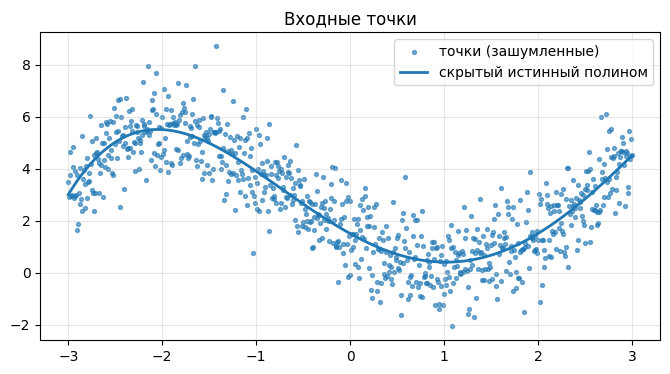

In [22]:
plt.figure(figsize=(8,4))
plt.scatter(x, y, s=8, alpha=0.6, label='точки (зашумленные)')
plt.plot(x, y_true, linewidth=2, label='скрытый истинный полином')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Входные точки')
plt.show()

### Этап 2. Представление индивида и фитнесс

- индивид: `params[i]` — коэффициенты $c_i$
- фитнесс: `sumError += (f_approx - point_y)^2`, т.е. **SSE**


In [23]:
def poly_eval(coeffs: np.ndarray, x: np.ndarray) -> np.ndarray:
    # coeffs: (N_GENES,) или (..., N_GENES)
    # возвращает y: (len(x),) или (..., len(x))
    powers = np.vstack([x**k for k in range(coeffs.shape[-1])])  # (N_GENES, N_POINTS)
    return np.tensordot(coeffs, powers, axes=([coeffs.ndim-1],[0]))

def fitness_sse(pop: np.ndarray, x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """SSE для каждого индивида. pop shape: (POP_SIZE, N_GENES)."""
    y_hat = poly_eval(pop, x)              # (POP_SIZE, N_POINTS)
    err = y_hat - y[None, :]
    return np.sum(err * err, axis=1)       # (POP_SIZE,)

### Этап 3. Операторы GA: селекция, кроссовер, мутация

- `Selection`: сортировка по фитнессу (лучшие в начале)
- `Crossover`: single-point crossover
- `Mutation`: случайное число мутаций (обычно 1–2% бит/генов); первый индивид оставляем (элитизм)

Здесь кроссовер выполняем **по позициям коэффициентов** (5 генов), а мутация — как добавление гауссовского шума к случайно выбранным генам.


In [24]:
def selection_sort(pop: np.ndarray, fit: np.ndarray):
    idx = np.argsort(fit)  # по возрастанию => лучшие в начале
    return pop[idx], fit[idx]

def crossover_single_point(parents: np.ndarray, target_pop_size: int) -> np.ndarray:
    """Генерирует новую популяцию с помощью одноточечного кроссовера по позициям генов."""
    n_par = parents.shape[0]
    children = []
    while len(children) < (target_pop_size - n_par):
        p1 = parents[np.random.randint(0, n_par)]
        p2 = parents[np.random.randint(0, n_par)]
        cp = np.random.randint(1, N_GENES)  # 1..N_GENES-1
        c1 = np.concatenate([p1[:cp], p2[cp:]])
        c2 = np.concatenate([p2[:cp], p1[cp:]])
        children.append(c1)
        if len(children) < (target_pop_size - n_par):
            children.append(c2)
    return np.vstack([parents, np.array(children, dtype=float)])

def mutation(pop: np.ndarray, E_m: float, D_m: float, elite_keep: int = 1,
             gene_sigma: float = 0.5, coeff_clip: float = 20.0) -> np.ndarray:
    """Мутирует случайные гены в популяции (исключая элиту)."""
    pop = pop.copy()
    n = pop.shape[0]
    total_genes = (n - elite_keep) * N_GENES
    frac = np.random.normal(loc=E_m, scale=np.sqrt(max(D_m, 0.0)))
    frac = float(np.clip(frac, 0.0, 0.2))  # ограничение
    mut_count = int(np.round(frac * total_genes))
    if mut_count <= 0:
        return pop

    # Выбираем индексы для неэлитной части
    for _ in range(mut_count):
        ind = np.random.randint(elite_keep, n)
        gene = np.random.randint(0, N_GENES)
        pop[ind, gene] += np.random.normal(loc=0.0, scale=gene_sigma)

    if coeff_clip is not None:
        pop = np.clip(pop, -coeff_clip, coeff_clip)
    return pop

### Этап 4. Основной цикл GA

- `generationNumber > maxIter`
- либо если лучший фитнесс не улучшается `maxConstIter` поколений


In [27]:
def genetic_algorithm(x: np.ndarray, y: np.ndarray,
                      pop_size: int,
                      max_iter: int,
                      max_const_iter: int,
                      E_m: float,
                      D_m: float,
                      elite_keep: int = 1,
                      parent_frac: float = 0.5,
                      init_sigma: float = 5.0):
    # Инициализация популяции (случайная; допускает нули)
    pop = np.random.normal(loc=0.0, scale=init_sigma, size=(pop_size, N_GENES))

    best_fit = np.inf
    best_c = None
    best_gen = 0
    no_improve = 0

    history = []

    t0 = time.perf_counter()
    for gen in range(1, max_iter + 1):
        fit = fitness_sse(pop, x, y)
        pop, fit = selection_sort(pop, fit)

        if fit[0] < best_fit - 1e-12:
            best_fit = float(fit[0])
            best_c = pop[0].copy()
            best_gen = gen
            no_improve = 0
        else:
            no_improve += 1

        history.append(best_fit)

        if no_improve >= max_const_iter:
            break

        # Кроссовер на лучшей половине (как в файле)
        n_parents = max(2, int(np.round(parent_frac * pop_size)))
        parents = pop[:n_parents]
        pop = crossover_single_point(parents, target_pop_size=pop_size)

        # Мутация
        pop = mutation(pop, E_m=E_m, D_m=D_m, elite_keep=elite_keep)

    t1 = time.perf_counter()

    return {
        "best_coeffs": best_c,
        "best_fitness": best_fit,
        "last_generation": gen,
        "best_generation": best_gen,
        "time_seconds": (t1 - t0),
        "history": np.array(history, dtype=float),
    }

### Этап 5. Запуск и результаты

- время обработки на GPU (в этом ноутбуке измеряем время CPU)
- коэффициенты полинома
- лучший фитнесс
- номер последнего поколения


In [28]:
res = genetic_algorithm(
    x=x,
    y=y,
    pop_size=POP_SIZE,
    max_iter=MAX_ITER,
    max_const_iter=MAX_CONST_ITER,
    E_m=E_m,
    D_m=D_m,
)


res["best_coeffs"], res["best_fitness"], res["last_generation"], res["time_seconds"]


(array([ 1.31237477, -2.14051784,  0.913168  ,  0.27275564, -0.07734002]),
 794.1476377487984,
 300,
 5.634532451999803)

In [29]:
best_c = res["best_coeffs"]
y_fit = sum(best_c[k] * x**k for k in range(N_GENES))

print("Best coeffs:", best_c)
print("Best fitness (SSE):", res["best_fitness"])
print("Last generation:", res["last_generation"])
print("Best found at generation:", res["best_generation"])
print("CPU time (s):", res["time_seconds"])


Best coeffs: [ 1.31237477 -2.14051784  0.913168    0.27275564 -0.07734002]
Best fitness (SSE): 794.1476377487984
Last generation: 300
Best found at generation: 300
CPU time (s): 5.634532451999803


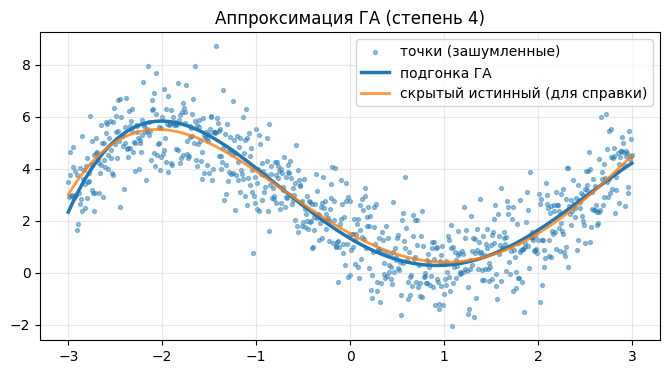

In [32]:
plt.figure(figsize=(8,4))
plt.scatter(x, y, s=8, alpha=0.45, label='точки (зашумленные)')
plt.plot(x, y_fit, linewidth=2.5, label='подгонка ГА')
plt.plot(x, y_true, linewidth=2, alpha=0.8, label='скрытый истинный (для справки)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Аппроксимация ГА (степень 4)')
plt.savefig('fig1.png')
plt.show()

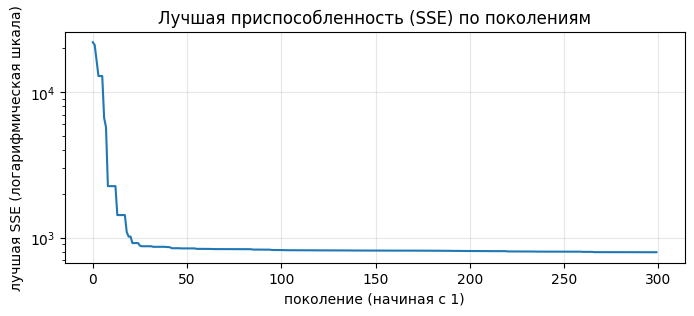

In [33]:
plt.figure(figsize=(8,3))
plt.plot(res["history"])
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.title('Лучшая приспособленность (SSE) по поколениям')
plt.xlabel('поколение (начиная с 1)')
plt.ylabel('лучшая SSE (логарифмическая шкала)')
plt.savefig('fig2.png')
plt.show()